FICO dataset obtained from https://github.com/fairmlbook/fairmlbook.github.io.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pickle as pkl

In [2]:
n_classes = 10

assert 200 % n_classes == 0

df_prob = pd.read_csv("data/fico_dist.csv")
df_perf = pd.read_csv("data/fico_perf.csv")


data = {}

step = 200 // n_classes

groups_occurence = {
    "Black" : 18_274,
    "White": 133_165
}
# normalize groups
total = sum(groups_occurence.values())
for col in groups_occurence:
    groups_occurence[col] = groups_occurence[col] / total

data["group_likelihoods"] = [groups_occurence[col] for col in ["Black", "White"]]


data["cluster_probabilities"] = []


for col in ["Black", "White"]:
    prob = df_prob[col].values
    prob = np.diff(prob)
    
    prob = [prob[i * step:(i + 1) * step].sum() for i in range(n_classes)]

    prob = np.array(prob)
    prob = prob / prob.sum()
    data["cluster_probabilities"].append(prob)


data["success_probabilities"] = []


for col in ["Black", "White"]:
    perf = df_perf[col].values
    perf = (100 - perf) / 100

    perf = [np.mean(perf[i * step:(i + 1) * step]) for i in range(n_classes)]

    data["success_probabilities"].append(perf)
    

In [3]:
with open("data/fico.pkl", "wb") as f:
    pkl.dump(data, f)

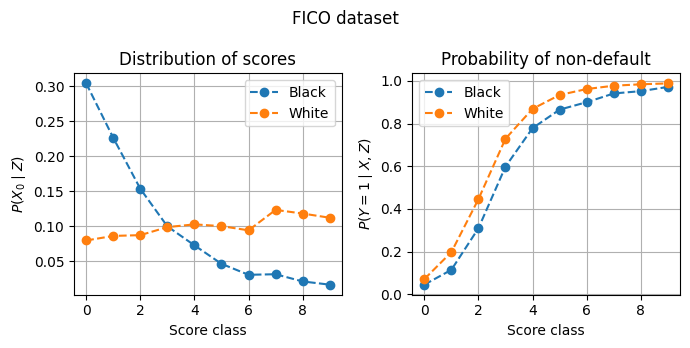

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))


for i, col in enumerate(["Black", "White"]):
    # plot distribution of scores

    axs[0].plot(
        data["cluster_probabilities"][i],
        label=col,
        marker="o",
        linestyle="--",
    )


    # plot probability of payment of each score
    axs[1].plot(
        data["success_probabilities"][i],
        label=col,
        marker="o",
        linestyle="--",
    )

    axs[0].set_ylabel("$P(X_0 \mid Z)$")

    axs[1].set_ylabel("$P(Y = 1 \mid X, Z)$")


    
for i in range(2):
    axs[i].set_xlabel("Score class")
    axs[i].legend()
    

axs[0].set_title("Distribution of scores")
axs[1].set_title("Probability of non-default")
for i in range(2):
    axs[i].grid()
plt.suptitle("FICO dataset")
plt.tight_layout()
plt.savefig("figures/fico.pdf", dpi = 300)
plt.show()